In [ ]:
storage_account = "waseekstr"
access_key = "**************************************************************************"

spark.conf.set(
    f"fs.azure.account.key.{storage_account}.blob.core.windows.net",
    access_key
)

print("📥 Loading ALL data from Bronze Layer...")
df_bronze = spark.read.csv(
    f"wasbs://glassdoor-data@{storage_account}.blob.core.windows.net/bronze/all_reviews.csv",
    header=True,
    inferSchema=True
)

total = df_bronze.count()
print(f"✅ Total records loaded: {total:,}")
print(f"✅ Total columns: {len(df_bronze.columns)}")
df_bronze.printSchema()

📥 Loading ALL data from Bronze Layer...
✅ Total records loaded: 657,876
✅ Total columns: 19
root
 |-- rating: string (nullable = true)
 |-- title: string (nullable = true)
 |-- status: string (nullable = true)
 |-- pros: string (nullable = true)
 |-- cons: string (nullable = true)
 |-- advice: string (nullable = true)
 |-- Recommend: string (nullable = true)
 |-- CEO Approval: string (nullable = true)
 |-- Business Outlook: string (nullable = true)
 |-- Career Opportunities: string (nullable = true)
 |-- Compensation and Benefits: string (nullable = true)
 |-- Senior Management: string (nullable = true)
 |-- Work/Life Balance: string (nullable = true)
 |-- Culture & Values: string (nullable = true)
 |-- Diversity & Inclusion: string (nullable = true)
 |-- firm_link: string (nullable = true)
 |-- date: string (nullable = true)
 |-- job: string (nullable = true)
 |-- index: string (nullable = true)



In [ ]:
from pyspark.sql.functions import col, count, when

print("=" * 60)
print("STEP 1: DATA PROFILING AND ASSESSMENT")
print("=" * 60)

print(f"\n📌 Total records     : {df_bronze.count():,}")
print(f"📌 Total columns     : {len(df_bronze.columns)}")

print("\n📊 Summary Statistics (numeric rating columns):")
df_bronze.describe([
    "rating", "Career Opportunities", "Compensation and Benefits",
    "Senior Management", "Work/Life Balance", "Culture & Values",
    "Diversity & Inclusion"
]).show()

print("\n📊 Null / Empty value counts per column:")
null_counts = df_bronze.select([
    count(when(col(c).isNull() | (col(c) == ""), c)).alias(c)
    for c in df_bronze.columns
])
null_counts.show(vertical=True)

dup_count = df_bronze.count() - df_bronze.dropDuplicates().count()
print(f"\n📌 Duplicate rows detected: {dup_count:,}")
print("\n✅ Step 1 Complete — Profiling done. Issues identified above.")

STEP 1: DATA PROFILING AND ASSESSMENT

📌 Total records     : 16,281,039
📌 Total columns     : 19

📊 Summary Statistics (numeric rating columns):
+-------+--------------------+--------------------+-------------------------+--------------------+--------------------+--------------------+---------------------+
|summary|              rating|Career Opportunities|Compensation and Benefits|   Senior Management|   Work/Life Balance|    Culture & Values|Diversity & Inclusion|
+-------+--------------------+--------------------+-------------------------+--------------------+--------------------+--------------------+---------------------+
|  count|            16280322|             7996886|                  7431072|             7717780|             8128500|             7924290|              3589000|
|   mean|   3.559336027011645|  3.3743574119423463|                 Infinity|   3.189234601929397|  3.3882502431150874|                 NaN|    4.690594175136936|
| stddev|  1.7670689232533983|   1.56683

Valid rows for plotting: 2,676,157


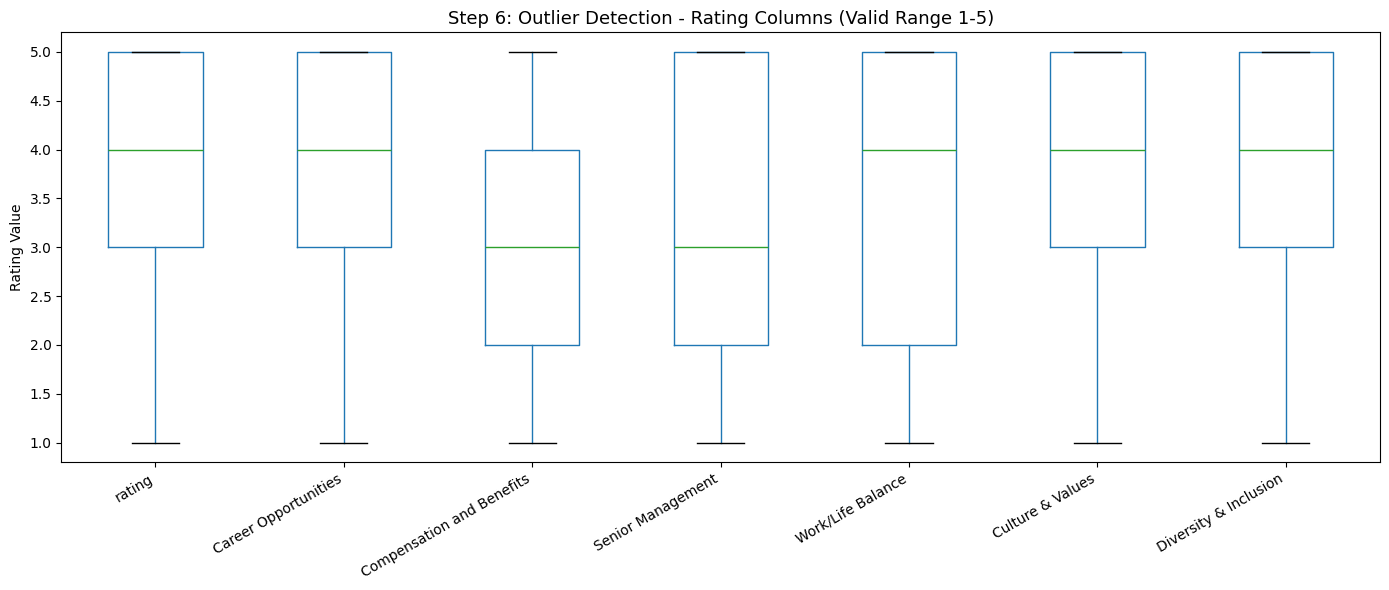


Outlier counts (values outside 1-5 range):
  rating: 165 outliers
  Career Opportunities: 21 outliers
  Compensation and Benefits: 11 outliers
  Senior Management: 15 outliers
  Work/Life Balance: 10 outliers
  Culture & Values: 24 outliers
  Diversity & Inclusion: 5,669 outliers


In [ ]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import col

rating_cols = [
    "rating", "Career Opportunities", "Compensation and Benefits",
    "Senior Management", "Work/Life Balance", "Culture & Values",
    "Diversity & Inclusion"
]

# try_cast tolerates malformed text and returns NULL instead of crashing
df_numeric = df_bronze
for c in rating_cols:
    df_numeric = df_numeric.withColumn(c, col(c).try_cast("double"))

# Keep ONLY valid rows: not null AND within the 1-5 rating range
valid = df_numeric
for c in rating_cols:
    valid = valid.filter(col(c).isNotNull() & (col(c) >= 1) & (col(c) <= 5))

print(f"Valid rows for plotting: {valid.count():,}")

# Sample down to a safe size for pandas/matplotlib
pdf = valid.select(rating_cols).limit(50000).toPandas()

fig, ax = plt.subplots(figsize=(14, 6))
pdf.boxplot(column=rating_cols, ax=ax, grid=False)
ax.set_title("Step 6: Outlier Detection - Rating Columns (Valid Range 1-5)", fontsize=13)
ax.set_ylabel("Rating Value")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Outlier counts on the FULL dataset (values outside 1-5)
print("\nOutlier counts (values outside 1-5 range):")
for c in rating_cols:
    outliers = df_numeric.filter((col(c) < 1) | (col(c) > 5)).count()
    print(f"  {c}: {outliers:,} outliers")

In [ ]:
from pyspark.sql.functions import col, lower, trim, try_to_date, regexp_extract, when

print("=" * 60)
print("STEP 2: FULL PRE-PROCESSING -> SILVER LAYER")
print("=" * 60)

rating_cols = [
    "rating", "Career Opportunities", "Compensation and Benefits",
    "Senior Management", "Work/Life Balance", "Culture & Values",
    "Diversity & Inclusion"
]

before = df_bronze.count()
print(f"\nRows before cleaning: {before:,}")

# --- 1. Cast rating columns safely (garbage text -> NULL) ---
df_clean = df_bronze
for c in rating_cols:
    df_clean = df_clean.withColumn(c, col(c).try_cast("double"))

# --- 2. Handle missing values ---
df_clean = df_clean.dropna(subset=["rating"])
df_clean = df_clean.filter((col("rating") >= 1) & (col("rating") <= 5))
df_clean = df_clean.fillna("", subset=["pros", "cons", "advice"])

# --- 3. Remove duplicates ---
df_clean = df_clean.dropDuplicates()

# --- 4. Date standardisation: 'Nov 19, 2022' -> proper date (try_to_date tolerates junk) ---
df_clean = df_clean.withColumn(
    "review_date", try_to_date(trim(col("date")), "MMM d, yyyy")
)

# --- 5. Text normalisation: lowercase + trim free-text fields ---
for c in ["pros", "cons", "advice"]:
    df_clean = df_clean.withColumn(c, lower(trim(col(c))))

# --- 6. Employment status parsing ---
df_clean = df_clean.withColumn(
    "employment_type",
    regexp_extract(col("status"), r"(Current Employee|Former Employee)", 1)
)
df_clean = df_clean.withColumn(
    "tenure",
    trim(regexp_extract(col("status"), r",\s*(.*)$", 1))
)

after = df_clean.count()
print(f"Rows after cleaning : {after:,}")
print(f"Rows removed        : {before - after:,}")
print("\nNew columns added: review_date, employment_type, tenure")
df_clean.select("status", "employment_type", "tenure", "date", "review_date") \
        .show(5, truncate=False)
print("\nStep 2 Complete - data cleaned, ready to write to Silver Layer.")

STEP 2: FULL PRE-PROCESSING -> SILVER LAYER

Rows before cleaning: 16,281,039
Rows after cleaning : 9,508,621
Rows removed        : 6,772,418

New columns added: review_date, employment_type, tenure
+----------------------------------+----------------+-----------------+-------------+-----------+
|status                            |employment_type |tenure           |date         |review_date|
+----------------------------------+----------------+-----------------+-------------+-----------+
|Current Employee, less than 1 year|Current Employee|less than 1 year |Feb 20, 2020 |2020-02-20 |
|Former Employee, more than 1 year |Former Employee |more than 1 year |Jun 2, 2019  |2019-06-02 |
|Former Employee, more than 1 year |Former Employee |more than 1 year |May 22, 2017 |2017-05-22 |
|Current Employee                  |Current Employee|                 |Sep 19, 2022 |2022-09-19 |
|Former Employee, more than 3 years|Former Employee |more than 3 years|NULL         |NULL       |
+----------------

In [ ]:
import re
from pyspark.sql.functions import year as year_fn

print("=" * 60)
print("STEP 3: WRITE CLEANED DATA TO SILVER LAYER (DELTA)")
print("=" * 60)

storage_account = "waseekstr"

# --- Clean column names: Delta forbids spaces and special chars ---
def clean_name(name):
    # replace any run of non-alphanumeric chars with a single underscore
    n = re.sub(r"[ ,;{}()\n\t=&/]+", "_", name)
    return n.strip("_")

df_silver = df_clean
for old in df_silver.columns:
    new = clean_name(old)
    if new != old:
        df_silver = df_silver.withColumnRenamed(old, new)

# Add 'year' column for partitioning (review_date -> year)
df_silver = df_silver.withColumn("year", year_fn(col("review_date")))

print("\nCleaned column names:")
print(df_silver.columns)

# Container is 'glassdoor-data', 'silver' is a folder inside it
silver_path = f"wasbs://glassdoor-data@{storage_account}.blob.core.windows.net/silver/glassdoor/"

print(f"\nWriting {df_silver.count():,} rows to Silver layer...")
print(f"Target: {silver_path}")

df_silver.write.format("delta") \
    .mode("overwrite") \
    .partitionBy("year") \
    .save(silver_path)

print("\nSilver layer write COMPLETE.")

# Verify by reading it back
df_check = spark.read.format("delta").load(silver_path)
print(f"Verification - rows read back from Silver: {df_check.count():,}")
print(f"Verification - columns: {len(df_check.columns)}")
df_check.printSchema()

STEP 3: WRITE CLEANED DATA TO SILVER LAYER (DELTA)

Cleaned column names:
['rating', 'title', 'status', 'pros', 'cons', 'advice', 'Recommend', 'CEO_Approval', 'Business_Outlook', 'Career_Opportunities', 'Compensation_and_Benefits', 'Senior_Management', 'Work_Life_Balance', 'Culture_Values', 'Diversity_Inclusion', 'firm_link', 'date', 'job', 'index', 'review_date', 'employment_type', 'tenure', 'year']

Writing 9,508,621 rows to Silver layer...
Target: wasbs://glassdoor-data@waseekstr.blob.core.windows.net/silver/glassdoor/

Silver layer write COMPLETE.
Verification - rows read back from Silver: 9,508,621
Verification - columns: 23
root
 |-- rating: double (nullable = true)
 |-- title: string (nullable = true)
 |-- status: string (nullable = true)
 |-- pros: string (nullable = true)
 |-- cons: string (nullable = true)
 |-- advice: string (nullable = true)
 |-- Recommend: string (nullable = true)
 |-- CEO_Approval: string (nullable = true)
 |-- Business_Outlook: string (nullable = true)
 

In [ ]:
# Install VADER (lexicon-based sentiment analyzer)
%pip install vaderSentiment

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from pyspark.sql.functions import col, udf
from pyspark.sql.types import FloatType

print("=" * 60)
print("STEP 4: VADER SENTIMENT ANALYSIS ON FREE-TEXT REVIEWS")
print("=" * 60)

storage_account = "waseekstr"
silver_path = f"wasbs://glassdoor-data@{storage_account}.blob.core.windows.net/silver/glassdoor/"

# Re-read Silver layer (memory cleared after %pip install)
df_silver = spark.read.format("delta").load(silver_path)
print(f"\nLoaded {df_silver.count():,} rows from Silver layer")

# Sample down for sentiment scoring (Python UDF is row-by-row, so we sample)
df_sample = df_silver.select("pros", "cons", "rating").limit(100000)

# VADER returns a compound score: -1 (most negative) to +1 (most positive)
analyzer = SentimentIntensityAnalyzer()

def vader_score(text):
    if text is None or text == "":
        return 0.0
    return float(analyzer.polarity_scores(text)["compound"])

sentiment_udf = udf(vader_score, FloatType())

df_sentiment = df_sample \
    .withColumn("pros_sentiment", sentiment_udf(col("pros"))) \
    .withColumn("cons_sentiment", sentiment_udf(col("cons")))

print("\nSample sentiment scores (pros should be positive, cons negative):")
df_sentiment.select("rating", "pros", "pros_sentiment", "cons", "cons_sentiment") \
            .show(8, truncate=40)

# Average sentiment summary
from pyspark.sql.functions import avg, round as round_fn
print("\nAverage sentiment scores across sample:")
df_sentiment.select(
    round_fn(avg("pros_sentiment"), 4).alias("avg_pros_sentiment"),
    round_fn(avg("cons_sentiment"), 4).alias("avg_cons_sentiment")
).show()

print("Step 4 Complete - VADER sentiment scoring done.")

STEP 4: VADER SENTIMENT ANALYSIS ON FREE-TEXT REVIEWS

Loaded 9,508,621 rows from Silver layer

Sample sentiment scores (pros should be positive, cons negative):
+------+----------------------------------------+--------------+----------------------------------------+--------------+
|rating|                                    pros|pros_sentiment|                                    cons|cons_sentiment|
+------+----------------------------------------+--------------+----------------------------------------+--------------+
|   4.0|there are great training opportunitie...|        0.9711|projects that are more geared towards...|        0.7906|
|   4.0|independence.i am free to chose my ow...|        0.6854|no communication on up coming promotions|        -0.296|
|   2.0|the company believes in promoting fro...|        0.9393|the company does not pay as competiti...|        0.7757|
|   3.0|when people hear you work for booz al...|        0.8689|client service is a big part of the b...|       

In [ ]:
from pyspark.sql.functions import col, round as round_fn
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

print("=" * 60)
print("STEP 5: RANDOM FOREST - RATING PREDICTION MODEL (TUNED)")
print("=" * 60)

features = [
    "Career_Opportunities", "Compensation_and_Benefits",
    "Work_Life_Balance", "Culture_Values",
    "Diversity_Inclusion", "Senior_Management"
]

# Cast features + label to double, keep only valid 1-5 rows
df_model = df_silver
for c in features + ["rating"]:
    df_model = df_model.withColumn(c, col(c).try_cast("double"))
df_model = df_model.dropna(subset=features + ["rating"])
for c in features + ["rating"]:
    df_model = df_model.filter((col(c) >= 1) & (col(c) <= 5))

print(f"\nRows available for modelling: {df_model.count():,}")

# Assemble features into a single vector
assembler = VectorAssembler(inputCols=features, outputCol="features")
df_assembled = assembler.transform(df_model).select("features", "rating")

# 80/20 train-test split
train, test = df_assembled.randomSplit([0.8, 0.2], seed=42)
train.cache(); test.cache()
print(f"Training rows: {train.count():,}  |  Test rows: {test.count():,}")

# Train tuned Random Forest
rf = RandomForestRegressor(
    featuresCol="features", labelCol="rating",
    numTrees=120, maxDepth=10, maxBins=32, seed=42
)
print("\nTraining tuned Random Forest (120 trees, maxDepth=10)...")
model = rf.fit(train)

predictions = model.transform(test)

# Evaluate
rmse = RegressionEvaluator(labelCol="rating", predictionCol="prediction",
                           metricName="rmse").evaluate(predictions)
mae = RegressionEvaluator(labelCol="rating", predictionCol="prediction",
                          metricName="mae").evaluate(predictions)
r2 = RegressionEvaluator(labelCol="rating", predictionCol="prediction",
                         metricName="r2").evaluate(predictions)

print("\n" + "=" * 40)
print("MODEL PERFORMANCE (TUNED)")
print("=" * 40)
print(f"RMSE (Root Mean Squared Error) : {rmse:.4f}")
print(f"MAE  (Mean Absolute Error)     : {mae:.4f}")
print(f"R2   (variance explained)      : {r2:.4f}")

print("\nFEATURE IMPORTANCE (which factors drive overall rating):")
importances = list(zip(features, model.featureImportances.toArray()))
importances.sort(key=lambda x: x[1], reverse=True)
for feat, imp in importances:
    print(f"  {feat:30s}: {imp:.4f}")

# Cleaner sample: random spread of ratings, rounded prediction
print("\nSample predictions vs actual (random spread):")
predictions.withColumn("prediction", round_fn(col("prediction"), 2)) \
           .select("rating", "prediction") \
           .orderBy(col("rating")) \
           .sample(fraction=0.001, seed=7) \
           .show(12)

print("Step 5 Complete - Tuned Random Forest model trained and evaluated.")

STEP 5: RANDOM FOREST - RATING PREDICTION MODEL (TUNED)

Rows available for modelling: 2,585,896
Training rows: 2,069,106  |  Test rows: 516,790

Training tuned Random Forest (120 trees, maxDepth=10)...

MODEL PERFORMANCE (TUNED)
RMSE (Root Mean Squared Error) : 0.6252
MAE  (Mean Absolute Error)     : 0.4540
R2   (variance explained)      : 0.7427

FEATURE IMPORTANCE (which factors drive overall rating):
  Culture_Values                : 0.3388
  Senior_Management             : 0.2496
  Career_Opportunities          : 0.2022
  Diversity_Inclusion           : 0.1124
  Work_Life_Balance             : 0.0606
  Compensation_and_Benefits     : 0.0365

Sample predictions vs actual (random spread):
+------+----------+
|rating|prediction|
+------+----------+
|   1.0|      1.25|
|   1.0|      1.25|
|   1.0|      1.25|
|   1.0|      1.44|
|   1.0|      2.27|
|   1.0|      2.31|
|   1.0|      2.95|
|   1.0|      1.25|
|   1.0|      1.25|
|   1.0|      1.25|
|   1.0|       1.4|
|   1.0|       1.3|

In [ ]:
from pyspark.sql.functions import col, avg, count, round as round_fn

print("=" * 60)
print("STEP 6: BUILD GOLD LAYER - ANALYTICS-READY TABLES")
print("=" * 60)

storage_account = "waseekstr"
gold_base = f"wasbs://glassdoor-data@{storage_account}.blob.core.windows.net/gold/"

rating_cols = ["rating", "Career_Opportunities", "Compensation_and_Benefits",
               "Senior_Management", "Work_Life_Balance", "Culture_Values",
               "Diversity_Inclusion"]
df_g = df_silver
for c in rating_cols:
    df_g = df_g.withColumn(c, col(c).try_cast("double"))
df_g = df_g.filter((col("rating") >= 1) & (col("rating") <= 5))

# --- GOLD TABLE 1: Average rating by year ---
gold_yearly = df_g.filter(col("year").isNotNull()) \
    .groupBy("year") \
    .agg(round_fn(avg("rating"), 2).alias("avg_rating"),
         count("*").alias("review_count")) \
    .orderBy("year")
print("\nGold Table 1 - Average rating by year:")
gold_yearly.show()
gold_yearly.write.format("delta").mode("overwrite").save(gold_base + "rating_by_year/")

# --- GOLD TABLE 2: Sub-dimension averages grouped by overall rating ---
gold_dimensions = df_g.groupBy("rating") \
    .agg(round_fn(avg("Career_Opportunities"), 2).alias("avg_career"),
         round_fn(avg("Compensation_and_Benefits"), 2).alias("avg_comp"),
         round_fn(avg("Work_Life_Balance"), 2).alias("avg_wlb"),
         round_fn(avg("Culture_Values"), 2).alias("avg_culture"),
         round_fn(avg("Diversity_Inclusion"), 2).alias("avg_di"),
         round_fn(avg("Senior_Management"), 2).alias("avg_mgmt")) \
    .orderBy(col("rating").desc())
print("Gold Table 2 - Sub-dimension averages by overall rating:")
gold_dimensions.show()
gold_dimensions.write.format("delta").mode("overwrite").save(gold_base + "dimension_averages/")

# --- GOLD TABLE 3: Stats by employment type ---
gold_employment = df_g.filter(col("employment_type") != "") \
    .groupBy("employment_type") \
    .agg(count("*").alias("total_reviews"),
         round_fn(avg("rating"), 2).alias("avg_rating")) \
    .orderBy("employment_type")
print("Gold Table 3 - Stats by employment type:")
gold_employment.show()
gold_employment.write.format("delta").mode("overwrite").save(gold_base + "employment_stats/")

# --- GOLD MAIN: enriched curated dataset for dashboards ---
gold_main = df_g.select(
    "rating", "Career_Opportunities", "Compensation_and_Benefits",
    "Senior_Management", "Work_Life_Balance", "Culture_Values",
    "Diversity_Inclusion", "Recommend", "CEO_Approval", "Business_Outlook",
    "employment_type", "tenure", "review_date", "year"
)
gold_main.write.format("delta").mode("overwrite").partitionBy("year").save(gold_base + "glassdoor_curated/")
print(f"\nGold main curated table written: {gold_main.count():,} rows")

print("\nStep 6 Complete - Gold layer built (4 tables).")


STEP 6: BUILD GOLD LAYER - ANALYTICS-READY TABLES

Gold Table 1 - Average rating by year:
+----+----------+------------+
|year|avg_rating|review_count|
+----+----------+------------+
|2008|      3.26|       29095|
|2009|      3.19|       29913|
|2010|      3.15|       52949|
|2011|       3.2|       69665|
|2012|      3.37|      133778|
|2013|      3.32|      182606|
|2014|      3.31|      313460|
|2015|      3.37|      529313|
|2016|      3.46|      582891|
|2017|       3.5|      586652|
|2018|      3.55|      520537|
|2019|       3.6|      540942|
|2020|      3.75|      772387|
|2021|      3.75|     1564885|
|2022|      3.77|     1417582|
|2023|      3.69|      448705|
+----+----------+------------+

Gold Table 2 - Sub-dimension averages by overall rating:
+------+----------+--------+-------+-----------+------+--------+
|rating|avg_career|avg_comp|avg_wlb|avg_culture|avg_di|avg_mgmt|
+------+----------+--------+-------+-----------+------+--------+
|   5.0|      4.52|    4.36|   4.39| 

In [ ]:
print("Generating CSV content for Power BI...")

storage_account = "waseekstr"
gold_base = f"wasbs://glassdoor-data@{storage_account}.blob.core.windows.net/gold/"

rating_by_year = spark.read.format("delta").load(gold_base + "rating_by_year/")
dimension_averages = spark.read.format("delta").load(gold_base + "dimension_averages/")
employment_stats = spark.read.format("delta").load(gold_base + "employment_stats/")

pdf_year = rating_by_year.toPandas().sort_values("year")
pdf_dim = dimension_averages.toPandas().sort_values("rating", ascending=False)
pdf_emp = employment_stats.toPandas()

print("\n" + "=" * 60)
print("FILE 1: gold_rating_by_year.csv")
print("=" * 60)
print(pdf_year.to_csv(index=False))

print("=" * 60)
print("FILE 2: gold_dimension_averages.csv")
print("=" * 60)
print(pdf_dim.to_csv(index=False))

print("=" * 60)
print("FILE 3: gold_employment_stats.csv")
print("=" * 60)
print(pdf_emp.to_csv(index=False))

print("=" * 60)
print("Done - copy each block above into a .csv file.")

Generating CSV content for Power BI...

FILE 1: gold_rating_by_year.csv
year,avg_rating,review_count
2008,3.26,29095
2009,3.19,29913
2010,3.15,52949
2011,3.2,69665
2012,3.37,133778
2013,3.32,182606
2014,3.31,313460
2015,3.37,529313
2016,3.46,582891
2017,3.5,586652
2018,3.55,520537
2019,3.6,540942
2020,3.75,772387
2021,3.75,1564885
2022,3.77,1417582
2023,3.69,448705

FILE 2: gold_dimension_averages.csv
rating,avg_career,avg_comp,avg_wlb,avg_culture,avg_di,avg_mgmt
5.0,4.52,4.36,4.39,4.68,4.68,4.43
4.0,3.71,3.62,3.68,3.96,4.09,3.52
3.1,,,,,,
3.0,2.92,2.97,2.97,3.01,3.41,2.56
2.6,,,,,,
2.5,,,,,,
2.0,2.15,2.45,2.32,2.06,2.7,1.71
1.0,1.44,1.86,1.64,1.35,1.82,1.2

FILE 3: gold_employment_stats.csv
employment_type,total_reviews,avg_rating
Current Employee,5475599,3.76
Former Employee,4018774,3.27

Done - copy each block above into a .csv file.


In [ ]:
from pyspark.sql.functions import col, avg, count, round as round_fn, trim

print("Building extra Gold aggregations + exporting all CSVs for Power BI...")

storage_account = "waseekstr"
gold_base = f"wasbs://glassdoor-data@{storage_account}.blob.core.windows.net/gold/"
silver_path = f"wasbs://glassdoor-data@{storage_account}.blob.core.windows.net/silver/glassdoor/"

# Read Silver layer for the new aggregations
df = spark.read.format("delta").load(silver_path)
df = df.withColumn("rating", col("rating").try_cast("double"))
df = df.filter((col("rating") >= 1) & (col("rating") <= 5))

# --- NEW GOLD TABLE 4: Rating distribution (count per star level, rounded) ---
from pyspark.sql.functions import floor
rating_dist = df.withColumn("star", floor(col("rating"))) \
    .groupBy("star").agg(count("*").alias("review_count")) \
    .orderBy("star")
rating_dist.write.format("delta").mode("overwrite").save(gold_base + "rating_distribution/")

# --- NEW GOLD TABLE 5: Recommendation breakdown ---
recommend_breakdown = df.filter(col("Recommend").isNotNull() & (trim(col("Recommend")) != "")) \
    .groupBy("Recommend").agg(count("*").alias("review_count")) \
    .orderBy(col("review_count").desc())
recommend_breakdown.write.format("delta").mode("overwrite").save(gold_base + "recommend_breakdown/")

# --- NEW GOLD TABLE 6: Average rating by tenure ---
tenure_stats = df.filter(col("tenure").isNotNull() & (trim(col("tenure")) != "")) \
    .groupBy("tenure") \
    .agg(count("*").alias("review_count"),
         round_fn(avg("rating"), 2).alias("avg_rating")) \
    .orderBy(col("review_count").desc())
tenure_stats.write.format("delta").mode("overwrite").save(gold_base + "tenure_stats/")

# --- Read back the 3 original Gold tables ---
rating_by_year = spark.read.format("delta").load(gold_base + "rating_by_year/")
dimension_averages = spark.read.format("delta").load(gold_base + "dimension_averages/")
employment_stats = spark.read.format("delta").load(gold_base + "employment_stats/")

# Convert all 6 to pandas
pdf_year = rating_by_year.toPandas().sort_values("year")
pdf_dim  = dimension_averages.toPandas().sort_values("rating", ascending=False)
pdf_emp  = employment_stats.toPandas()
pdf_dist = rating_dist.toPandas()
pdf_rec  = recommend_breakdown.toPandas()
pdf_ten  = tenure_stats.toPandas()

files = [
    ("gold_rating_by_year.csv", pdf_year),
    ("gold_dimension_averages.csv", pdf_dim),
    ("gold_employment_stats.csv", pdf_emp),
    ("gold_rating_distribution.csv", pdf_dist),
    ("gold_recommend_breakdown.csv", pdf_rec),
    ("gold_tenure_stats.csv", pdf_ten),
]

for i, (name, pdf) in enumerate(files, 1):
    print("\n" + "=" * 60)
    print(f"FILE {i}: {name}  ({len(pdf)} rows)")
    print("=" * 60)
    print(pdf.to_csv(index=False))

print("=" * 60)
print("Done - 6 CSV files. Copy each block into a .csv file.")

Building extra Gold aggregations + exporting all CSVs for Power BI...

FILE 1: gold_rating_by_year.csv  (16 rows)
year,avg_rating,review_count
2008,3.26,29095
2009,3.19,29913
2010,3.15,52949
2011,3.2,69665
2012,3.37,133778
2013,3.32,182606
2014,3.31,313460
2015,3.37,529313
2016,3.46,582891
2017,3.5,586652
2018,3.55,520537
2019,3.6,540942
2020,3.75,772387
2021,3.75,1564885
2022,3.77,1417582
2023,3.69,448705


FILE 2: gold_dimension_averages.csv  (8 rows)
rating,avg_career,avg_comp,avg_wlb,avg_culture,avg_di,avg_mgmt
5.0,4.52,4.36,4.39,4.68,4.68,4.43
4.0,3.71,3.62,3.68,3.96,4.09,3.52
3.1,,,,,,
3.0,2.92,2.97,2.97,3.01,3.41,2.56
2.6,,,,,,
2.5,,,,,,
2.0,2.15,2.45,2.32,2.06,2.7,1.71
1.0,1.44,1.86,1.64,1.35,1.82,1.2


FILE 3: gold_employment_stats.csv  (2 rows)
employment_type,total_reviews,avg_rating
Current Employee,5475599,3.76
Former Employee,4018774,3.27


FILE 4: gold_rating_distribution.csv  (5 rows)
star,review_count
1,890622
2,985039
3,2206607
4,2839702
5,2586651


FILE 5: gold_recom

Recommend,review_count
v,3608216
o,2423371
x,1743834
" etc.""",109
 however,67
 etc.,23
 benefits,20
 etc,19
" 2016 """,18
" 2015 """,17
" 2022 """,16
" 2017 """,16
 HR,16
" etc.)""",15
" 2021 """,15
4,15
r,15
 again,14
" 2014 """,14
 bonuses,14
 training,13
3,12
 in fact,12
 sell,12
" 2020 """,12
1,12
" so they aren't usually at the same time daily.""",11
 the rules are different. Little or no communications betweed departments that work closely together. There are no set processes. Some people get away with murder,11
The cloud of despair that looms everywhere.,11
 long hours,11
" no paid vacation.""",11
" they will not. It is a """"Puppet Masters at work environment"""".  Any  new person realizes this within once they view all of the departments. Starting at the bottom floor. They even lowered the severance package from two weeks for every year of employment to one.""",11
 managers,11
" you are fine.  Do not spend a lot of time there if you are a talented individual.""",11
"If you're

In [ ]:
from pyspark.sql.functions import col, avg, count, round as round_fn, trim, floor

print("Building CLEAN Gold aggregations for Power BI...")

storage_account = "waseekstr"
gold_base = f"wasbs://glassdoor-data@{storage_account}.blob.core.windows.net/gold/"
silver_path = f"wasbs://glassdoor-data@{storage_account}.blob.core.windows.net/silver/glassdoor/"

df = spark.read.format("delta").load(silver_path)
df = df.withColumn("rating", col("rating").try_cast("double"))
df = df.filter((col("rating") >= 1) & (col("rating") <= 5))

# --- TABLE 4: Rating distribution ---
rating_dist = df.withColumn("star", floor(col("rating"))) \
    .groupBy("star").agg(count("*").alias("review_count")).orderBy("star")
rating_dist.write.format("delta").mode("overwrite").save(gold_base + "rating_distribution/")

# --- TABLE 5: Recommendation breakdown - ONLY valid codes v / x / o ---
recommend_breakdown = df.filter(col("Recommend").isin("v", "x", "o")) \
    .groupBy("Recommend").agg(count("*").alias("review_count")) \
    .orderBy(col("review_count").desc())
recommend_breakdown.write.format("delta").mode("overwrite").save(gold_base + "recommend_breakdown/")

# --- TABLE 6: Tenure stats - ONLY the 6 valid tenure bands ---
valid_tenure = [
    "less than 1 year", "more than 1 year", "more than 3 years",
    "more than 5 years", "more than 8 years", "more than 10 years"
]
tenure_stats = df.filter(col("tenure").isin(valid_tenure)) \
    .groupBy("tenure") \
    .agg(count("*").alias("review_count"),
         round_fn(avg("rating"), 2).alias("avg_rating")) \
    .orderBy(col("review_count").desc())
tenure_stats.write.format("delta").mode("overwrite").save(gold_base + "tenure_stats/")

# Print only the two fixed tables (you already have files 1-4)
pdf_rec = recommend_breakdown.toPandas()
pdf_ten = tenure_stats.toPandas()

print("\n" + "=" * 60)
print(f"FILE 5: gold_recommend_breakdown.csv  ({len(pdf_rec)} rows)")
print("=" * 60)
print(pdf_rec.to_csv(index=False))

print("=" * 60)
print(f"FILE 6: gold_tenure_stats.csv  ({len(pdf_ten)} rows)")
print("=" * 60)
print(pdf_ten.to_csv(index=False))

print("=" * 60)
print("Done - both files should now be small and clean.")

Building CLEAN Gold aggregations for Power BI...

FILE 5: gold_recommend_breakdown.csv  (3 rows)
Recommend,review_count
v,3608216
o,2423371
x,1743834

FILE 6: gold_tenure_stats.csv  (6 rows)
tenure,review_count,avg_rating
more than 1 year,1734099,3.49
less than 1 year,1243942,3.52
more than 3 years,1207195,3.51
more than 5 years,721534,3.52
more than 10 years,448373,3.58
more than 8 years,347800,3.54

Done - both files should now be small and clean.
